# PoC: Clasificador canto de Aves (Iteración 0)

Alejandro Morales

The following is a detailed description of the fields of this object:

- gen: the generic name of the species
- sp: the specific name (epithet) of the species
- ssp: the subspecies name (subspecific epithet)
- grp: the group to which the species belongs (birds, grasshoppers, bats)
- type: the sound type of the recording (combining both predefined terms such as 'call' or 'song' and additional free text options)
- sex: the sex of the animal
- stage: the life stage of the animal (adult, juvenile, etc.)
- q: the current quality rating for the recording
- also: an array with the identified background species in the recording
- animal-seen: was the recorded animal seen?
- smp: sample rate
- method

## EDA

In [1]:
import pandas as pd
import os

In [2]:
import librosa
import librosa.display
from IPython.display import Audio, display
import matplotlib.pyplot as plt
import numpy as np

In [24]:
def safe(fn):
    def wrapper(x):
        try:
            return fn(x)
        except Exception as e:
            return e  # o None, o (x, e)
    return wrapper

In [61]:
from mutagen.mp3 import MP3
db_path = "../../aves_colombia"
is_mp3 = lambda fn: fn.endswith(".mp3")
to_full_path = lambda filename: os.path.join(db_path, filename)
to_safe_mp3 = lambda fn: (fn, safe(MP3)(fn))
is_not_an_exception = lambda tuple: not isinstance(tuple[1], Exception)
extract_tags = lambda info: {"length": info.length, "sample_rate": info.sample_rate, "bitrate": info.bitrate, "channels":info.channels}
to_tags_of_interest = lambda tuple: (tuple[0], extract_tags(tuple[1].info))
to_consolided_dict = lambda tuple: {"filename": tuple[0].replace(db_path, ''), **tuple[1]}

metadata = list(
    map(to_consolided_dict,
        map(to_tags_of_interest,
            filter(is_not_an_exception,
                map(to_safe_mp3,
                    map(to_full_path,
                        filter(is_mp3, os.listdir(db_path))
                    )
                )
            )
        )
    )
)


In [38]:
df = pd.DataFrame(data=metadata)

In [39]:
df

,filename,length,sample_rate,bitrate,channels
0,/XC235597_Basileuterus_delattrii.mp3,11.145062,44100,128000,1
1,/XC449318_Crypturellus_cinereus.mp3,25.656054,44100,320000,2
2,/XC440007_Nothocercus_bonapartei.mp3,22.805333,48000,245378,2
3,/XC59637_Grallaria_spatiator.mp3,8.588125,48000,128000,2
4,/XC117440_Crypturellus_cinereus.mp3,194.213333,44100,123702,2
...,...,...,...,...,...
516,/XC335143_Pyriglena_maura.mp3,24.906259,44100,192000,1
517,/XC54924_Crypturellus_cinereus.mp3,81.459312,44100,128000,1
518,/XC54224_Crypturellus_soui.mp3,3.596500,44100,64000,1
519,/XC117255_Crypturellus_soui.mp3,178.520000,44100,95928,2


In [78]:
df[["genero", "subgenero"]] = df["filename"].str.extract(r"XC\d+_([^_]+)_([^_.]+)")

In [79]:
df

,filename,length,sample_rate,bitrate,channels,genero,subgenero
0,/XC235597_Basileuterus_delattrii.mp3,11.145062,44100,128000,1,Basileuterus,delattrii
1,/XC449318_Crypturellus_cinereus.mp3,25.656054,44100,320000,2,Crypturellus,cinereus
2,/XC440007_Nothocercus_bonapartei.mp3,22.805333,48000,245378,2,Nothocercus,bonapartei
3,/XC59637_Grallaria_spatiator.mp3,8.588125,48000,128000,2,Grallaria,spatiator
4,/XC117440_Crypturellus_cinereus.mp3,194.213333,44100,123702,2,Crypturellus,cinereus
...,...,...,...,...,...,...,...
516,/XC335143_Pyriglena_maura.mp3,24.906259,44100,192000,1,Pyriglena,maura
517,/XC54924_Crypturellus_cinereus.mp3,81.459312,44100,128000,1,Crypturellus,cinereus
518,/XC54224_Crypturellus_soui.mp3,3.596500,44100,64000,1,Crypturellus,soui
519,/XC117255_Crypturellus_soui.mp3,178.520000,44100,95928,2,Crypturellus,soui


In [88]:
df['sample_rate'].value_counts()


sample_rate
44100    373
48000    121
32000     16
24000      5
16000      4
8000       1
11025      1
Name: count, dtype: int64

In [82]:
aux = df[['genero', 'subgenero']].value_counts()
aux.head()

genero        subgenero 
Crypturellus  soui          89
              cinereus      68
Saltator      olivascens    42
Nothocercus   julius        40
Basileuterus  delattrii     33
Name: count, dtype: int64

In [84]:
aux.shape
# aves en el dataset

(57,)

In [50]:
len(os.listdir(db_path))

596

In [65]:
# hay algunos archivos que no se pudieron abrir
diff = list(set(os.listdir(db_path)) - set(df['filename'].str.replace('/', '').values))

In [66]:
len(diff)

75

In [40]:
df['sample_rate'].value_counts()

sample_rate
44100    373
48000    121
32000     16
24000      5
16000      4
8000       1
11025      1
Name: count, dtype: int64

In [41]:
df['channels'].value_counts()

channels
2    334
1    187
Name: count, dtype: int64

In [42]:
import seaborn as sns

In [44]:
df['length'].mean()

np.float64(106.25332549980942)

<Axes: xlabel='length', ylabel='Count'>

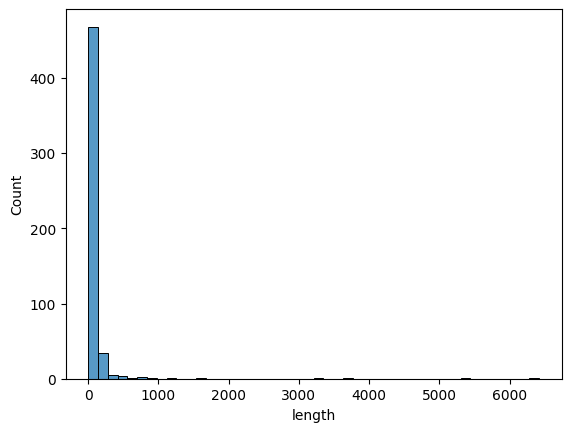

In [48]:
sns.histplot(data=df, x='length')

<Axes: xlabel='length', ylabel='Count'>

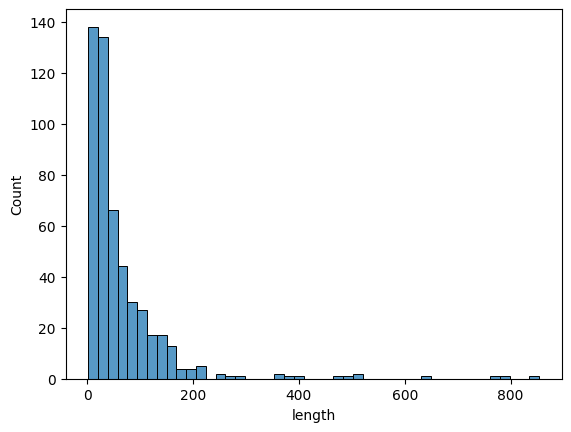

In [ ]:
# hagamos zoom
sns.histplot(data=df.query("length < 1000"), x='length')

In [85]:
# miremos algunos outlayers
df.query("length > 200").sort_values(by='length')

,filename,length,sample_rate,bitrate,channels,genero,subgenero
339,/XC199263_Crypturellus_cinereus.mp3,210.050612,44100,128000,2,Crypturellus,cinereus
460,/XC117376_Crypturellus_cinereus.mp3,212.653333,44100,126903,2,Crypturellus,cinereus
132,/XC1084655_Hyalinobatrachium_aureoguttatum.mp3,220.114286,32000,224000,2,Hyalinobatrachium,aureoguttatum
210,/XC1102815_Scinax_ruber.mp3,222.746625,48000,128000,2,Scinax,ruber
285,/XC236216_Tinamus_tao.mp3,223.623188,44100,128000,1,Tinamus,tao
291,/XC117400_Crypturellus_cinereus.mp3,243.026667,44100,122539,2,Crypturellus,cinereus
300,/XC1092263_Scinax_kennedyi.mp3,248.820812,44100,256000,1,Scinax,kennedyi
279,/XC1103506_Hyalinobatrachium_esmeralda.mp3,264.341200,48000,160000,2,Hyalinobatrachium,esmeralda
441,/XC117814_Crypturellus_soui.mp3,283.946667,44100,122501,2,Crypturellus,soui
412,/XC529311_Pyriglena_maura.mp3,356.674350,44100,160000,2,Pyriglena,maura


In [96]:

def crear_espectrograma(y, sr_bio, n, hop_length, ruta_salida_img):
    
    stft = librosa.stft(y, n_fft=n, hop_length=hop_length)
    stft_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)
    
    # 3. Graficar y guardar
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(stft_db, sr=sr_bio, hop_length=hop_length, x_axis='time', y_axis='hz', cmap='viridis')
    
    plt.axis("off")
    #plt.colorbar(format='%+2.0f dB')
    #plt.title('Espectrograma Lineal (Hz) - Canto de Ave')
    plt.tight_layout()
    plt.savefig(ruta_salida_img, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close()


In [122]:
def crear_waveform(y, sr_bio, n, hop, ruta_salida_img):

    fig, ax1 = plt.subplots(figsize=(10, 4))

    librosa.display.waveshow(y, sr=sr_bio)
    ax1.set_ylabel("Waveform")

    rms = librosa.feature.rms(y=y, frame_length=n, hop_length=hop)[0]
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=n, hop_length=hop)[0]
    frames = range(len(rms))
    t = librosa.frames_to_time(frames, sr=sr_bio, hop_length=hop)

    ax2 = ax1.twinx()
    ax2.plot(t, rms, color="orange", label="RMS")
    ax2.plot(t, zcr, color="green", label="ZCR")
    ax2.set_ylabel("RMS / ZCR")
    ax2.legend(loc="upper right")

    #plt.axis("off")
    plt.tight_layout()
    plt.savefig(ruta_salida_img, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close()

In [93]:
 # 1. Cargar el audio. 
n = 2048
hop = 512
y, sr = librosa.load('../../aves_colombia/XC1140313_Anhima_cornuta.mp3', sr=22050)


In [114]:
crear_espectrograma( y, sr, n, hop, 'espectrograma_ave.png')

In [123]:
crear_waveform(y, sr, n, hop, 'waveform_ave.png')

In [ ]:
# TODO, definir una heuristica para audio activity detection
# TODO: normalizar canales